# Customer & Subscriber EDA

Analysis of user types, demographics, and trip duration, with comparisons between Customers and Subscribers.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("preprocessing/cleaned_fordgobike_data.csv")

print("Shape:", df.shape)
df.head()

Shape: (181509, 26)


,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,...,start_time_td,end_time_td,start_minute,end_minute,member_age,duration_min,weekday,is_weekend,age_group,user_type_encoded
0,1585,NaN,2026-09-10 20:44:06,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,...,NaN,NaN,NaN,NaN,45.0,26.416667,NaN,False,31-45,1
1,1793,NaN,2026-09-10 19:51:48,93.0,4th St at Mission Bay Blvd S,37.770407,-122.391198,323.0,Broadway at Kearny,37.798014,...,NaN,NaN,NaN,NaN,60.0,29.883333,NaN,False,46-60,1
2,1147,NaN,2026-09-10 14:42:36,300.0,Palm St at Willow St,37.317298,-121.884995,312.0,San Jose Diridon Station,37.329732,...,NaN,NaN,NaN,NaN,36.0,19.116667,NaN,False,31-45,1
3,1615,NaN,2026-09-10 08:02:48,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,...,NaN,NaN,NaN,NaN,30.0,26.916667,NaN,False,18-30,1
4,1570,NaN,2026-09-10 07:59:42,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,...,NaN,NaN,NaN,NaN,31.0,26.166667,NaN,False,31-45,1


In [3]:
user_type_counts = df["user_type"].value_counts()

print(user_type_counts)

user_type
Subscriber    162715
Customer       18794
Name: count, dtype: int64


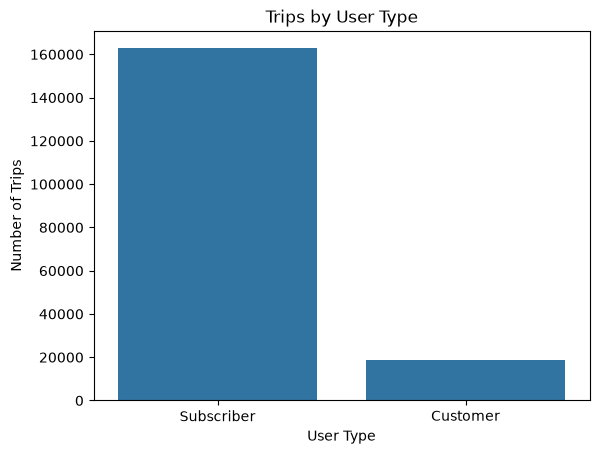

In [4]:
sns.countplot(data=df, x="user_type")

plt.title("Trips by User Type")
plt.xlabel("User Type")
plt.ylabel("Number of Trips")
plt.show()

### Interpretation

Subscribers made significantly more trips than Customers, showing that they are the dominant user type in the dataset.

In [5]:
user_type_percentage = df["user_type"].value_counts(normalize=True) * 100

print(user_type_percentage.round(2))

user_type
Subscriber    89.65
Customer      10.35
Name: proportion, dtype: float64


In [6]:
gender_counts = df["member_gender"].value_counts()

print(gender_counts)

member_gender
Male       129574
Female      40419
Unknown      7943
Other        3573
Name: count, dtype: int64


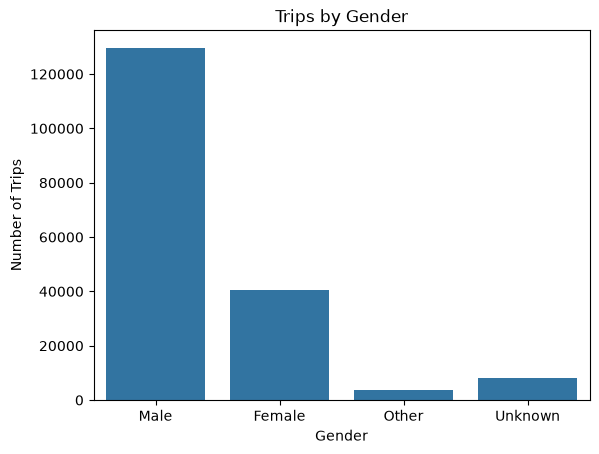

In [7]:
sns.countplot(data=df, x="member_gender")

plt.title("Trips by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Trips")
plt.show()

### Interpretation

The chart shows the distribution of recorded trips by gender and identifies the gender with the highest number of trips.

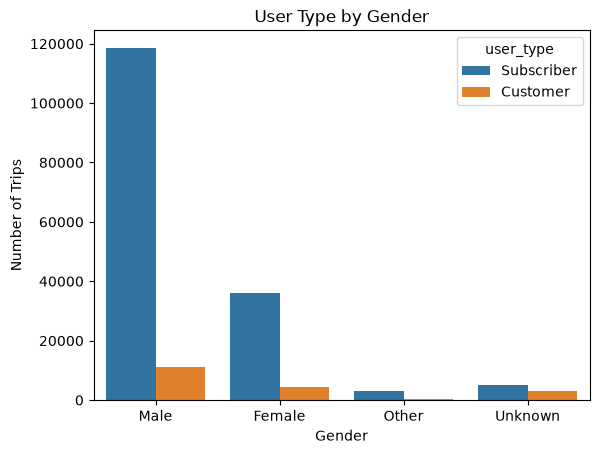

In [8]:
sns.countplot(data=df, x="member_gender", hue="user_type")

plt.title("User Type by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Trips")
plt.show()

### Interpretation

Subscribers account for the majority of trips across the recorded gender categories, while the distribution of Customers varies by gender.

In [9]:
age_group_counts = df["age_group"].value_counts().sort_index()

print(age_group_counts)

age_group
18-30       73644
31-45       76353
46-60       20036
60+          3317
Under 18       29
Name: count, dtype: int64


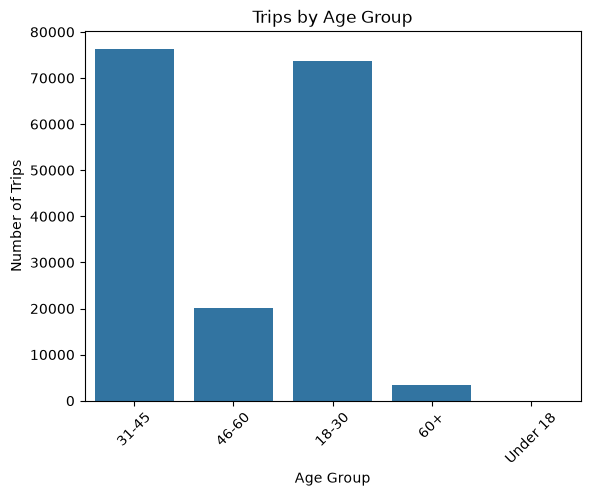

In [10]:
sns.countplot(data=df, x="age_group")

plt.title("Trips by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45)
plt.show()

### Interpretation

The 31-45 age group recorded the most trips (76,353), followed by 18-30 (73,644), 46-60 (20,036), and 60+ (3,317). Under 18 recorded only 29 trips. Overall, most trips were made by users aged 18-45.

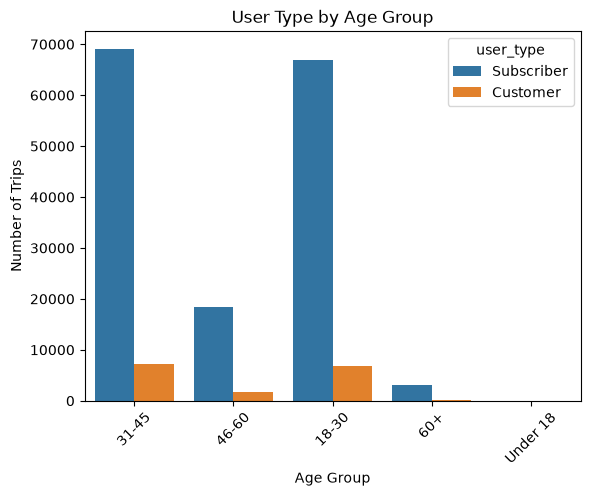

In [11]:
sns.countplot(data=df, x="age_group", hue="user_type")

plt.title("User Type by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45)
plt.show()

### Interpretation

Subscribers represented the majority of trips in the main age groups: 90.81% (18-30), 90.52% (31-45), 91.73% (46-60), and 94.69% (60+). Customers accounted for 5.31%-9.48%. Under 18 showed a different pattern, with Customers at 79.31% and Subscribers at 20.69%, but this is based on only 29 trips and should be interpreted with caution.

In [12]:
age_user = pd.crosstab(df["age_group"], df["user_type"])

print(age_user)

user_type  Customer  Subscriber
age_group                      
18-30          6766       66878
31-45          7235       69118
46-60          1657       18379
60+             176        3141
Under 18         23           6


In [13]:
age_user_percentage = pd.crosstab(
    df["age_group"],
    df["user_type"],
    normalize="index"
) * 100

print(age_user_percentage.round(2))

user_type  Customer  Subscriber
age_group                      
18-30          9.19       90.81
31-45          9.48       90.52
46-60          8.27       91.73
60+            5.31       94.69
Under 18      79.31       20.69


## Average Age by User Type

In [14]:
average_age = df.groupby("user_type")["member_age"].mean()

print(average_age.round(2))

user_type
Customer      33.61
Subscriber    34.17
Name: member_age, dtype: float64


### Interpretation

Customers had an average age of 33.61 years, while Subscribers averaged 34.17 years. The small difference indicates that both user types have very similar average ages.

## Trip Duration by User Type

In [15]:
average_duration = df.groupby("user_type")["duration_min"].mean()

print(average_duration.round(2))

user_type
Customer      15.21
Subscriber     9.84
Name: duration_min, dtype: float64


### Interpretation

Customers had a higher average trip duration (15.21 minutes) than Subscribers (9.84 minutes), indicating that Customers tend to spend more time per trip despite making fewer trips.

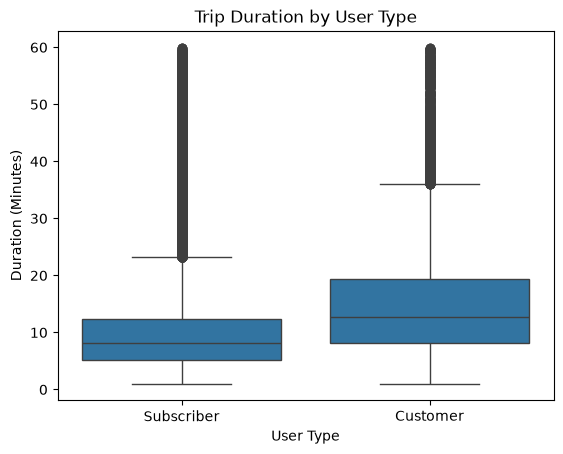

In [16]:
sns.boxplot(data=df, x="user_type", y="duration_min")

plt.title("Trip Duration by User Type")
plt.xlabel("User Type")
plt.ylabel("Duration (Minutes)")
plt.show()

### Interpretation

The boxplot shows differences in trip-duration distribution and spread between Customers and Subscribers, with Customers generally having longer trips.

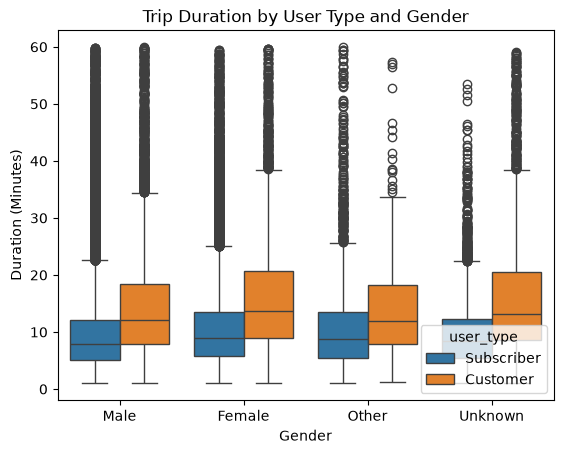

In [17]:
sns.boxplot(
    data=df,
    x="member_gender",
    y="duration_min",
    hue="user_type"
)

plt.title("Trip Duration by User Type and Gender")
plt.xlabel("Gender")
plt.ylabel("Duration (Minutes)")

plt.show()

### Interpretation

The chart compares trip duration across gender and user type, showing how trip duration differs between Customers and Subscribers within each gender category.

In [18]:
summary = df.groupby("user_type").agg(
    trips=("user_type", "size"),
    average_age=("member_age", "mean"),
    average_duration=("duration_min", "mean")
)

summary.round(2)

,trips,average_age,average_duration
user_type,,,
Customer,18794,33.61,15.21
Subscriber,162715,34.17,9.84


## Key Findings

- Subscribers made the majority of trips (162,715), compared with 18,794 trips by Customers.
- The 31-45 age group had the most trips (76,353), followed by 18-30 (73,644).
- Most trips were made by users aged 18-45.
- Subscribers accounted for more than 90% of trips across the main age groups from 18 to 60+.
- Customers had a higher average trip duration (15.21 minutes) than Subscribers (9.84 minutes).
- Average age was very similar for Customers (33.61) and Subscribers (34.17).
- The Under 18 group had a different user-type distribution, but only 29 trips were recorded.
- Overall, Subscribers generated most trips, while Customers had longer trips on average.